<a href="https://www.kaggle.com/code/lalit7881/indiana-properties-2026?scriptVersionId=304955149" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/kanchana1990/indiana-real-estate-data-2026/indiana_real_estate_2026.csv


## Loading dataset

In [2]:
# Load the CSV
file_path = "/kaggle/input/datasets/kanchana1990/indiana-real-estate-data-2026/indiana_real_estate_2026.csv"
df = pd.read_csv(file_path)

# Basic overview
print(df.head())       # Show first 5 rows
print(df.info())       # Data types and missing values
print(df.describe())   # Statistical summary of numeric columns

            type sub_type                                               text  \
0  single_family      NaN  1975 "Decor" Time Capsule hits market for the ...   
1  single_family      NaN  A peaceful country setting, generous acreage, ...   
2  single_family      NaN  **Open House Sunday March 22, from 2-4pm**Luxu...   
3  single_family      NaN  Charming 1.5 story home set on 2.25 peaceful a...   
4  single_family      NaN  THIS ESTATE HOME IS READY FOR YOU TO RESTORE A...   

   listPrice    sqft  stories  beds  baths  baths_full  baths_full_calc  \
0   194900.0  1646.0      1.0   3.0    2.0         2.0              2.0   
1   279000.0  2796.0      1.0   3.0    3.0         2.0              2.0   
2   640000.0  3871.0      2.0   5.0    3.0         2.0              2.0   
3   279900.0  4080.0      2.0   4.0    2.0         2.0              2.0   
4    89900.0  1152.0      1.0   3.0    2.0         1.0              1.0   

   garage  year_built  
0     2.0      1975.0  
1     2.0      1984.

In [3]:
print(df.shape)         # Number of rows and columns
print(df.columns)       # Column names
print(df.isnull().sum())# Count missing values per column

(13532, 12)
Index(['type', 'sub_type', 'text', 'listPrice', 'sqft', 'stories', 'beds',
       'baths', 'baths_full', 'baths_full_calc', 'garage', 'year_built'],
      dtype='object')
type                   0
sub_type           12711
text                 150
listPrice              0
sqft                2614
stories             2951
beds                2542
baths               3130
baths_full          2608
baths_full_calc     2590
garage              4334
year_built          3857
dtype: int64


## Handle missing values

In [4]:
missing = df.isnull().sum()
print(missing[missing > 0])  # Show only columns with missing values

sub_type           12711
text                 150
sqft                2614
stories             2951
beds                2542
baths               3130
baths_full          2608
baths_full_calc     2590
garage              4334
year_built          3857
dtype: int64


In [5]:
avg_price_type = df.groupby('type')['listPrice'].mean()
print(avg_price_type)

type
apartment        574343.111111
condos           341586.828947
farm             859907.329480
land             347836.043783
multi_family     334837.305296
multifamily      312413.333333
single_family    371735.254149
townhome         346070.517241
townhomes        355820.335793
unknown          267990.000000
Name: listPrice, dtype: float64


In [6]:
print(df['sqft'].describe())

count    10918.000000
mean      2107.080234
std       1276.492528
min          0.000000
25%       1402.000000
50%       1853.000000
75%       2506.000000
max      50762.000000
Name: sqft, dtype: float64


## Top 10 most expensive homes:

In [7]:
top10 = df.sort_values(by='listPrice', ascending=False).head(10)
print(top10[['type','sub_type','listPrice','sqft','beds','baths']])

                type sub_type   listPrice     sqft  beds  baths
1021   single_family      NaN  47900000.0  50762.0  15.0   19.0
13292           land      NaN  16014440.0      NaN   NaN    NaN
5361            land      NaN  11570000.0      NaN   NaN    NaN
12355           land      NaN  11497660.0      NaN   NaN    0.0
9059            land      NaN  10305000.0      NaN   NaN    NaN
9338            land      NaN  10190848.0      NaN   NaN    NaN
8036            farm      NaN   9535020.0      NaN   NaN    NaN
11805           land      NaN   8309922.0      NaN   NaN    NaN
10263           land      NaN   8258008.0      NaN   NaN    NaN
1443   single_family      NaN   7200000.0   9143.0   6.0    7.0


## Average price per property type:

In [8]:
df['age'] = 2026 - df['year_built']
print(df['age'].describe())

count    9675.000000
mean       48.474522
std        42.286040
min        -1.000000
25%         7.000000
50%        40.000000
75%        76.000000
max       226.000000
Name: age, dtype: float64


## Distribution of square footage:

In [9]:
print(df['sqft'].describe())

count    10918.000000
mean      2107.080234
std       1276.492528
min          0.000000
25%       1402.000000
50%       1853.000000
75%       2506.000000
max      50762.000000
Name: sqft, dtype: float64


## Age of properties:

In [10]:
df['age'] = 2026 - df['year_built']
print(df['age'].describe())

count    9675.000000
mean       48.474522
std        42.286040
min        -1.000000
25%         7.000000
50%        40.000000
75%        76.000000
max       226.000000
Name: age, dtype: float64


## EDA

In [11]:
# Fill missing values (simplified)
numeric_cols = ['listPrice', 'sqft', 'beds', 'baths', 'baths_full', 'baths_full_calc', 'year_built']
categorical_cols = ['type', 'sub_type', 'garage']

for col in numeric_cols:
    df[col].fillna(df[col].median(), inplace=True)
for col in categorical_cols:
    df[col].fillna('Unknown', inplace=True)


In [12]:
# Add age column
df['age'] = 2026 - df['year_built']

# Set seaborn style
sns.set_style("whitegrid")

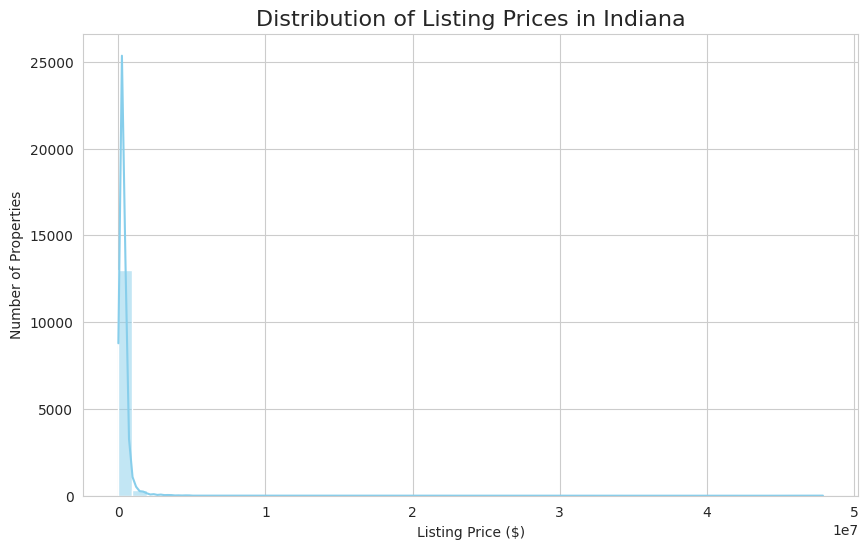

In [13]:
plt.figure(figsize=(10,6))
sns.histplot(df['listPrice'], bins=50, kde=True, color='skyblue')
plt.title("Distribution of Listing Prices in Indiana", fontsize=16)
plt.xlabel("Listing Price ($)")
plt.ylabel("Number of Properties")
plt.show()

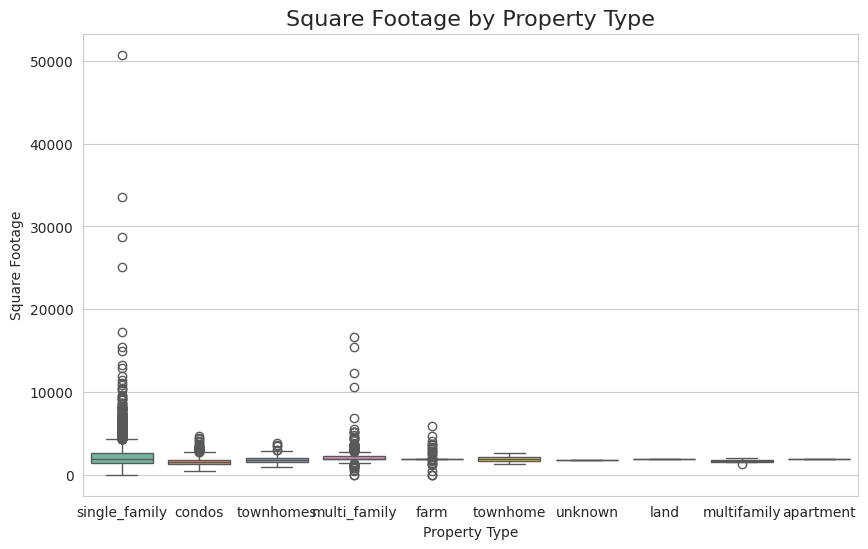

In [14]:
plt.figure(figsize=(10,6))
sns.boxplot(x='type', y='sqft', data=df, palette="Set2")
plt.title("Square Footage by Property Type", fontsize=16)
plt.xlabel("Property Type")
plt.ylabel("Square Footage")
plt.show()

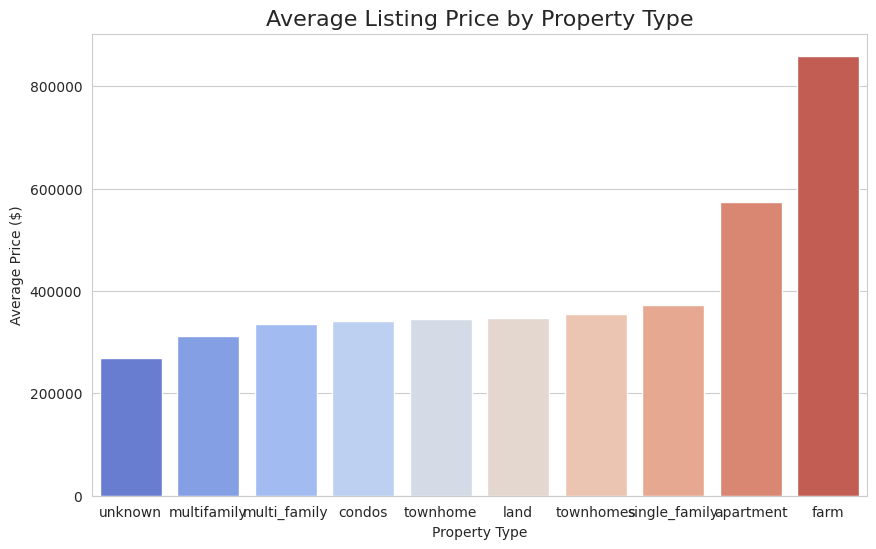

In [15]:
avg_price_type = df.groupby('type')['listPrice'].mean().sort_values()
plt.figure(figsize=(10,6))
sns.barplot(x=avg_price_type.index, y=avg_price_type.values, palette='coolwarm')
plt.title("Average Listing Price by Property Type", fontsize=16)
plt.xlabel("Property Type")
plt.ylabel("Average Price ($)")
plt.show()

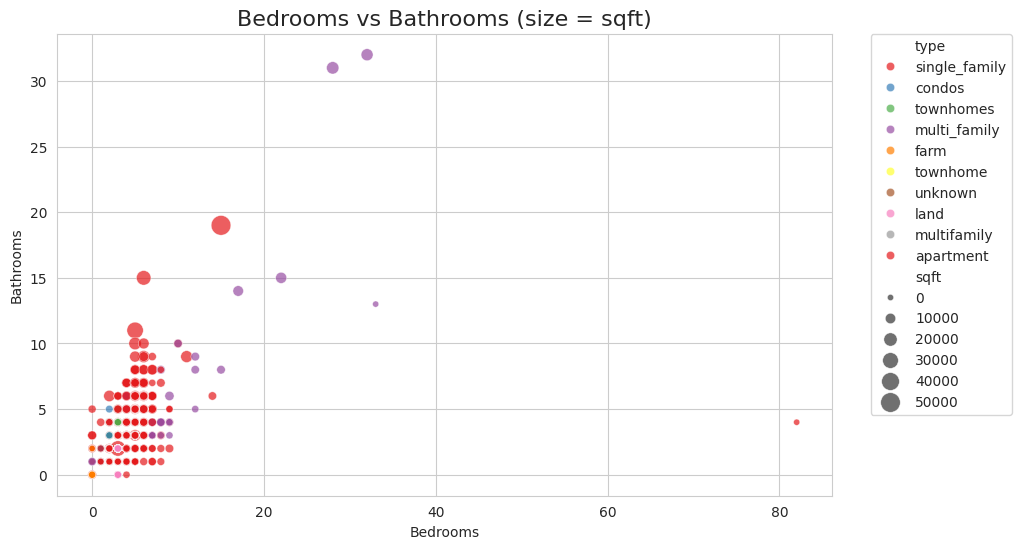

In [16]:
plt.figure(figsize=(10,6))
sns.scatterplot(x='beds', y='baths', hue='type', size='sqft', sizes=(20,200),
                palette='Set1', alpha=0.7, data=df)
plt.title("Bedrooms vs Bathrooms (size = sqft)", fontsize=16)
plt.xlabel("Bedrooms")
plt.ylabel("Bathrooms")
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
plt.show()

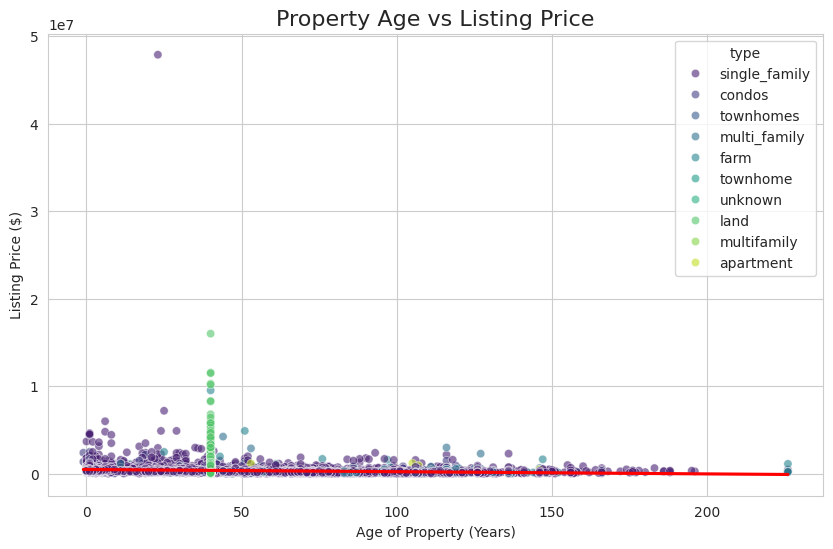

In [17]:
plt.figure(figsize=(10,6))
sns.scatterplot(x='age', y='listPrice', hue='type', palette='viridis', alpha=0.6, data=df)
sns.regplot(x='age', y='listPrice', data=df, scatter=False, color='red')
plt.title("Property Age vs Listing Price", fontsize=16)
plt.xlabel("Age of Property (Years)")
plt.ylabel("Listing Price ($)")
plt.show()

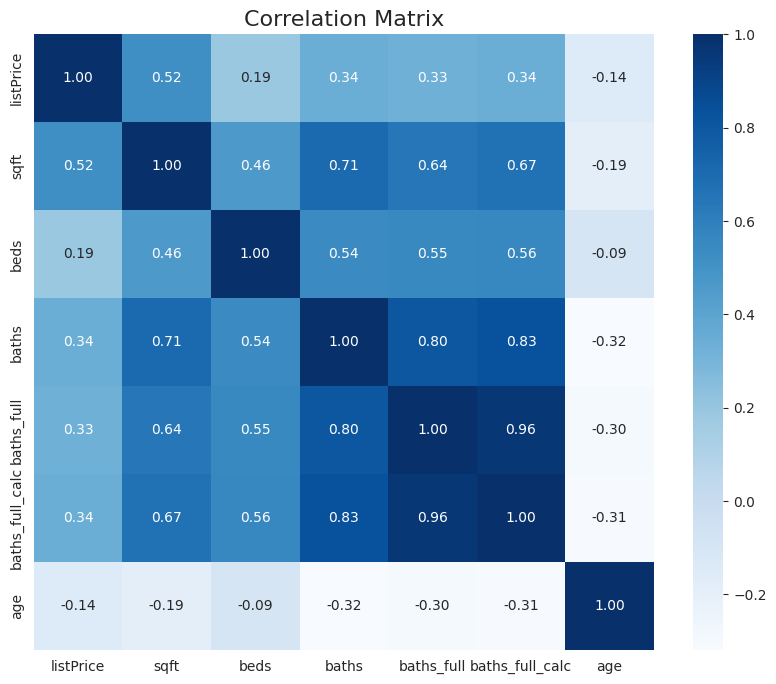

In [18]:
plt.figure(figsize=(10,8))
corr = df[['listPrice','sqft','beds','baths','baths_full','baths_full_calc','age']].corr()
sns.heatmap(corr, annot=True, cmap='Blues', fmt=".2f")
plt.title("Correlation Matrix", fontsize=16)
plt.show()

## Feature engineering

In [19]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, roc_curve, auc

In [20]:
numeric_cols = ['listPrice', 'sqft', 'beds', 'baths', 'baths_full', 'baths_full_calc', 'year_built']
categorical_cols = ['type', 'sub_type', 'garage']

for col in numeric_cols:
    df[col].fillna(df[col].median(), inplace=True)
for col in categorical_cols:
    df[col].fillna('Unknown', inplace=True)


In [21]:
median_price = df['listPrice'].median()
df['price_category'] = df['listPrice'].apply(lambda x: 'High' if x > median_price else 'Low')

In [22]:
for col in categorical_cols + ['price_category']:
    df[col] = df[col].astype(str)

# Now apply LabelEncoder
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
for col in categorical_cols + ['price_category']:
    df[col] = le.fit_transform(df[col])

print(df[categorical_cols + ['price_category']].head())

   type  sub_type  garage  price_category
0     6         0       4               1
1     6         0       4               1
2     6         0       4               0
3     6         0       4               1
4     6         0      15               1


In [23]:
le = LabelEncoder()
for col in categorical_cols + ['price_category']:
    df[col] = le.fit_transform(df[col])

In [24]:
features = ['type','sub_type','sqft','stories','beds','baths','baths_full','baths_full_calc','garage','year_built']
X = df[features]
y = df['price_category']

In [25]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [26]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [27]:
y_pred = rf.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Random Forest Accuracy: {accuracy*100:.2f}%")


Random Forest Accuracy: 84.45%


In [28]:
y_prob = rf.predict_proba(X_test)[:,1]


In [29]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)


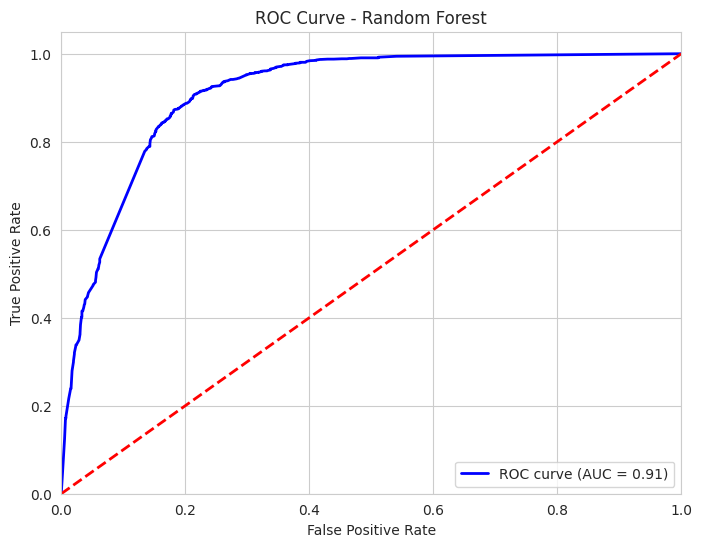

In [30]:
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0,1], [0,1], color='red', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Random Forest')
plt.legend(loc="lower right")
plt.show()

## Thank you..pls upvote!!!!!!!!!